In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/covid_19_data.csv')
print (df.head())
print (df.shape)
print (df.columns)


        Date State       Region  Confirmed  Deaths  Recovered
0  4/29/2020   NaN  Afghanistan       1939      60        252
1  4/29/2020   NaN      Albania        766      30        455
2  4/29/2020   NaN      Algeria       3848     444       1702
3  4/29/2020   NaN      Andorra        743      42        423
4  4/29/2020   NaN       Angola         27       2          7
(321, 6)
Index(['Date', 'State', 'Region', 'Confirmed', 'Deaths', 'Recovered'], dtype='object')


In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       321 non-null    object
 1   State      140 non-null    object
 2   Region     321 non-null    object
 3   Confirmed  321 non-null    int64 
 4   Deaths     321 non-null    int64 
 5   Recovered  321 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 15.2+ KB


,Confirmed,Deaths,Recovered
count,321.000000,321.000000,321.000000
mean,9949.800623,709.152648,3030.277259
std,31923.853086,3236.162817,14364.870365
min,0.000000,0.000000,0.000000
25%,104.000000,2.000000,2.000000
50%,653.000000,12.000000,73.000000
75%,4655.000000,144.000000,587.000000
max,299691.000000,27682.000000,132929.000000


In [16]:
df.isnull().sum()

,0
Date,0
State,181
Region,0
Confirmed,0
Deaths,0
Recovered,0


In [17]:
df.fillna(0)

,Date,State,Region,Confirmed,Deaths,Recovered
0,4/29/2020,0,Afghanistan,1939,60,252
1,4/29/2020,0,Albania,766,30,455
2,4/29/2020,0,Algeria,3848,444,1702
3,4/29/2020,0,Andorra,743,42,423
4,4/29/2020,0,Angola,27,2,7
...,...,...,...,...,...,...
316,4/29/2020,Wyoming,US,545,7,0
317,4/29/2020,Xinjiang,Mainland China,76,3,73
318,4/29/2020,Yukon,Canada,11,0,0
319,4/29/2020,Yunnan,Mainland China,185,2,181


In [31]:
df['Date'] = pd.to_datetime(df['Date'])
df.isnull().sum()


,0
Date,0
Region,0
Confirmed,0
Deaths,0
Recovered,0


In [34]:
india = df[df['Region']=='India']


In [ ]:
countries = df[df['Region'].isin(['India','US','UK','Brazil'])]

In [36]:
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']
df['Month'] = df['Date'].dt.month

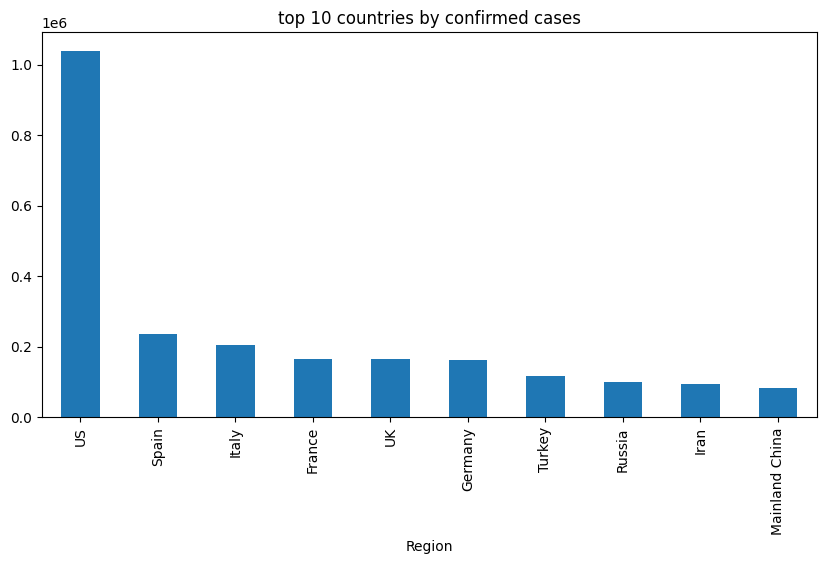

In [38]:
top_confirmed = df.groupby('Region')['Confirmed'].sum().sort_values(ascending=False).head(10)
top_confirmed.plot(kind='bar',figsize=(10,5))
plt.title("top 10 countries by confirmed cases")
plt.show()

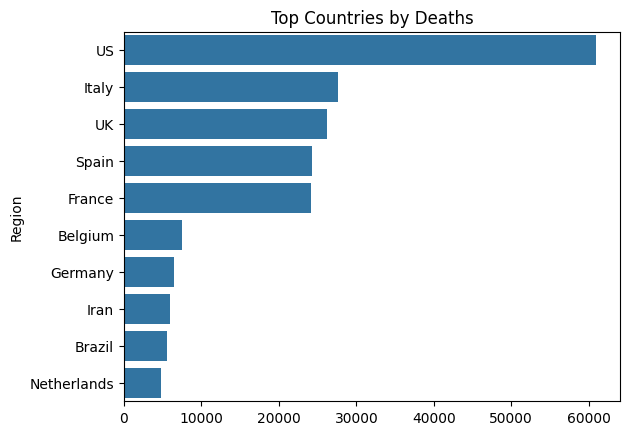

In [39]:
top_deaths = df.groupby('Region')['Deaths'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_deaths.values, y=top_deaths.index)
plt.title("Top Countries by Deaths")
plt.show()

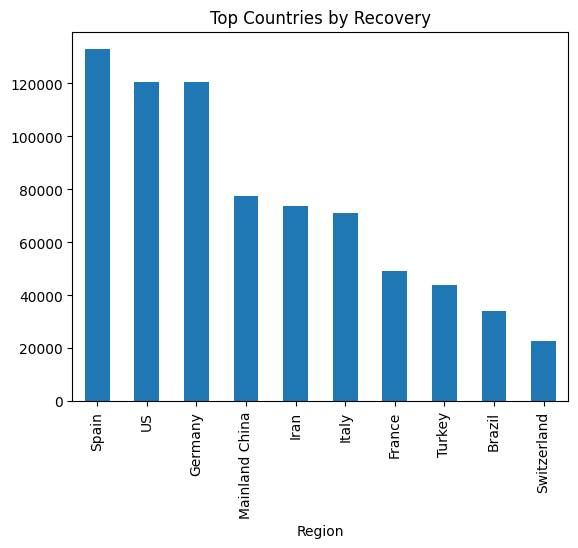

In [40]:
top_recovered = df.groupby('Region')['Recovered'].sum().sort_values(ascending=False).head(10)

top_recovered.plot(kind='bar')
plt.title("Top Countries by Recovery")
plt.show()

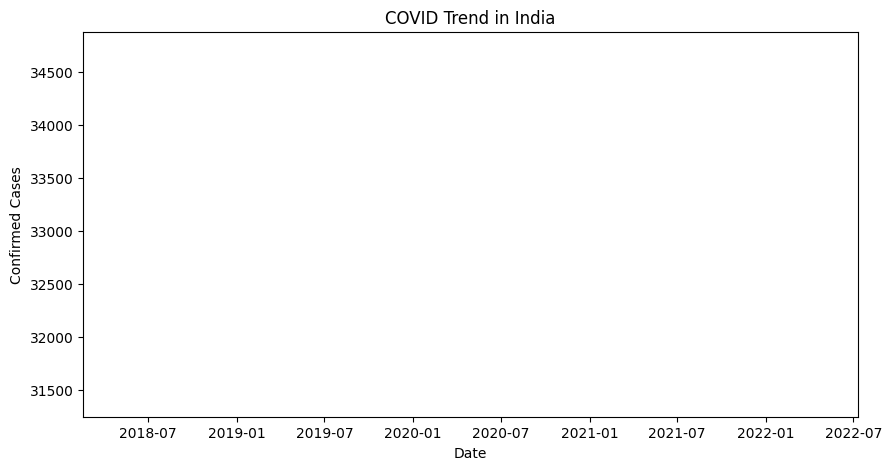

In [41]:
plt.figure(figsize=(10,5))
plt.plot(india['Date'], india['Confirmed'])
plt.title("COVID Trend in India")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

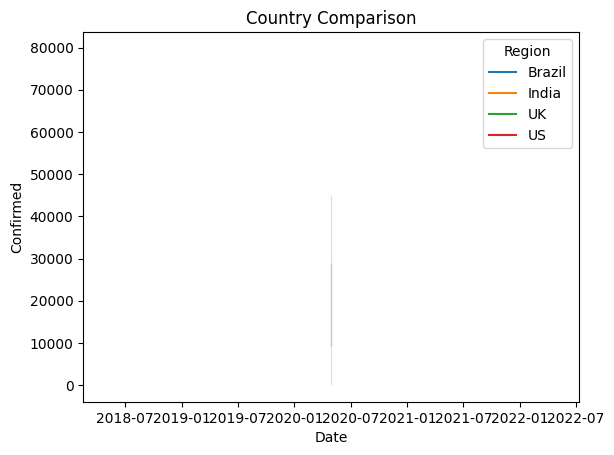

In [46]:
countries = df[df['Region'].isin(['India', 'US', 'UK', 'Brazil'])]
sns.lineplot(data=countries, x='Date', y='Confirmed', hue='Region')
plt.title("Country Comparison")
plt.show()

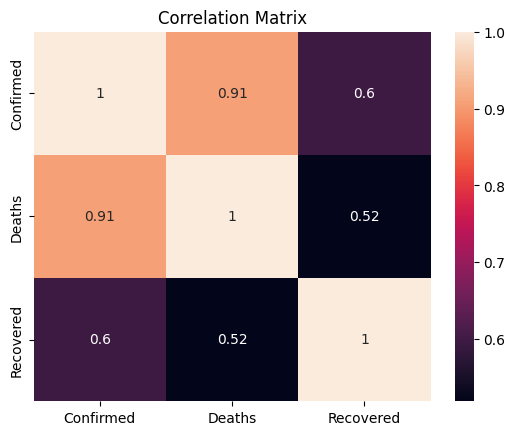

In [47]:
sns.heatmap(df[['Confirmed', 'Deaths', 'Recovered']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

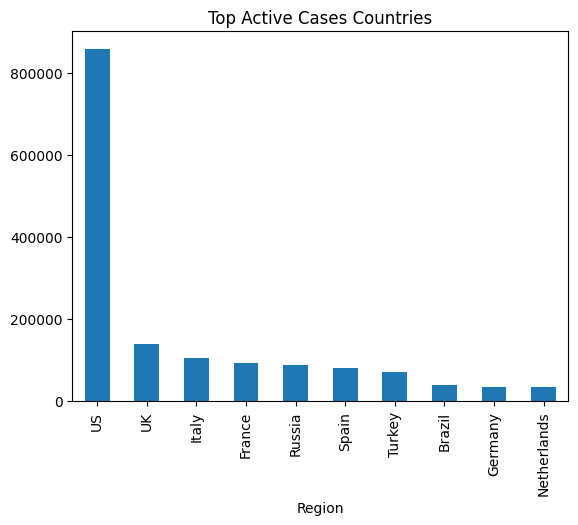

In [48]:
top_active = df.groupby('Region')['Active'].sum().sort_values(ascending=False).head(10)

top_active.plot(kind='bar')
plt.title("Top Active Cases Countries")
plt.show()

In [50]:
print(np.max(df['Confirmed']))
print(np.max(df['Deaths']))
print(np.max(df['Recovered']))

299691
27682
132929
